# Train model v3: model giao dịch theo sự kiện bất thường

**Ý tưởng.** Không dự báo trên mọi nến nữa. Chỉ học trên các nến **bất thường**, vì sau những nến này giá chạy nhanh và xa hơn:
- **E1:** nến 5m có range ≥ 0.5% giá và ≥ 3× trung vị 48 nến trước.
- **E2:** biến động 3 nến 5m gần nhất ≥ 2.5× 45 nến trước đó.
- **E3:** trong nến 5m vừa đóng có một nến 1m có range **và** volume ≥ 6× trung vị 4h trước.

**Nhãn = kết quả giao dịch thật** trên nến 1m, tính cho cả long và short:
- vào lệnh market ở nến 1m đầu tiên sau khi nến 5m đóng;
- SL = 2×σ(1h), tối thiểu 0.6%, và **TP = SL**;
- giữ tối đa 4h.

Model XGBoost dự báo P(TP), P(SL), P(hết giờ), rồi tính R kỳ vọng sau phí. Lệnh chỉ được vào khi R kỳ vọng ≥ ngưỡng, và ngưỡng được chọn trên năm validation.

**Feature** gồm:
- đặc điểm nến sự kiện;
- bất thường nến 1m;
- dấu hiệu nén/bùng nổ trước chuyển động mạnh;
- xu hướng;
- **pivot zigzag đã xác nhận với ngưỡng 1%**;
- dòng lệnh taker, funding.

Walk-forward theo năm: train < Y−1, validation = Y−1, test = Y.

⚠ Bước bổ sung nến mới cần mạng. Đặt `TOP_UP = False` để chỉ dùng CSV.

In [1]:
from pathlib import Path
import importlib, json, sys, time, warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "model_training":
    PROJECT_ROOT = PROJECT_ROOT.parent
MODEL_DIR = PROJECT_ROOT / "model_training"
if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))
import modelv3 as v3
import market_data as md
v3, md = importlib.reload(v3), importlib.reload(md)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)
plt.style.use("seaborn-v0_8-whitegrid")

## CONFIG

In [2]:
# ============================== CONFIG ==============================
HIST = PROJECT_ROOT / "historical_data"
OUT = PROJECT_ROOT / "artifacts" / "5m_event_v3"
TOP_UP = True                      # bổ sung nến 1m + funding mới qua REST
START = "2020-07-01"
RECENT_DAYS = 30

CFG = v3.Config(
    e1_min_range=0.005, e1_rel=3.0, e2_ratio=2.5, e3_rel=6.0, e3_vol_rel=6.0,
    pivot_thresholds=(0.01,),      # pivot đã xác nhận khi giá đảo chiều >= 1%
    tp_mult=1.0,                   # TP = SL
    sl_vol_mult=2.0, sl_min=0.006, sl_max=0.03,
    hold_min=240, fee_roundtrip=0.001,
    eval_years=(2022, 2023, 2024, 2025, 2026),
    device="cpu",                  # "cuda" nếu có GPU
)
# ====================================================================
OUT.mkdir(parents=True, exist_ok=True)

## 1. Dữ liệu

In [3]:
t0 = time.time()
m1 = md.load_klines(HIST / "BTCUSDT_1m_all.csv", "1m", top_up=TOP_UP)
m1 = v3.standardize_m1(m1)
m1 = m1[m1["t"] >= pd.Timestamp(START, tz="UTC").value // 1_000_000].reset_index(drop=True)
fund = pd.read_csv(HIST / "BTCUSDT_funding.csv")[["funding_time_ms", "funding_rate"]]
if TOP_UP:
    fund = pd.concat([fund, md.fetch_funding(int(fund["funding_time_ms"].max()) + 1)])
fund = v3.funding_table(fund)
gaps = int((np.diff(m1["t"].to_numpy()) != v3.M1).sum())
print(f"1m: {len(m1):,} nến → {pd.to_datetime(m1['t'].iloc[-1], unit='ms', utc=True)} | gaps {gaps} | "
      f"thiếu trades/taker: {int(m1['tb'].isna().sum())} | funding {len(fund)} | {time.time() - t0:.0f}s")

t0 = time.time()
data = v3.build_dataset(m1, fund, CFG)
ev, bars, spec = data["events"], data["bars"], data["spec"]
print(f"{len(bars):,} nến 5m | {len(ev):,} sự kiện ({len(ev) / (len(bars) / 288):.1f}/ngày) | {len(spec.names)} feature | {time.time() - t0:.0f}s")

1m: +116 candles from REST (to 2026-10-08 21:54:00+00:00)
1m: 3,298,914 nến → 2026-10-08 21:53:00+00:00 | gaps 0 | thiếu trades/taker: 0 | funding 6873 | 16s
659,782 nến 5m | 29,363 sự kiện (12.8/ngày) | 65 feature | 63s


## 2. Kiểm chứng: sau nến bất thường giá có chạy nhanh hơn không?

Chỉ dùng để mô tả, không dùng để chọn model. `move_1h` = |lợi nhuận 1h tới|, `P(≥1% trong 4h)` = xác suất giá đi được ≥1% về một phía trong 4h.

In [4]:
c, h, l = bars["close"].to_numpy(), None, None
b5 = v3.to_5m(m1)
hh, ll = b5["h"].to_numpy(), b5["l"].to_numpy()
from numpy.lib.stride_tricks import sliding_window_view as swv
H = 48
fwd_hi = np.full(len(b5), np.nan); fwd_lo = fwd_hi.copy(); fwd_1h = fwd_hi.copy()
fwd_hi[:-H] = swv(hh[1:], H).max(1)[:len(b5) - H] / c[:-H] - 1
fwd_lo[:-H] = 1 - swv(ll[1:], H).min(1)[:len(b5) - H] / c[:-H]
fwd_1h[:-12] = np.abs(c[12:] / c[:-12] - 1)
st = pd.DataFrame({"move_1h": fwd_1h, "big": np.maximum(fwd_hi, fwd_lo) >= 0.01}, index=bars.index)
rows = []
for name, mask in [("mọi nến", bars["warm"]), ("E1 nến 5m bất thường", bars["E1"] > 0), ("E2 3 nến bùng nổ", bars["E2"] > 0),
                   ("E3 bất thường 1m", bars["E3"] > 0), ("bất kỳ sự kiện", bars["is_event"])]:
    s = st[mask & bars["warm"]]
    rows.append({"nhóm": name, "số nến": len(s), "mỗi ngày": len(s) / (bars["warm"].sum() / 288),
                 "move_1h %": 100 * s["move_1h"].mean(), "P(≥1% trong 4h)": s["big"].mean()})
display(pd.DataFrame(rows).set_index("nhóm").round(3))

,số nến,mỗi ngày,move_1h %,P(≥1% trong 4h)
nhóm,,,,
mọi nến,656902,288.000,0.379,0.501
E1 nến 5m bất thường,12660,5.550,0.720,0.781
E2 3 nến bùng nổ,16388,7.185,0.557,0.609
E3 bất thường 1m,16814,7.372,0.460,0.508
bất kỳ sự kiện,29363,12.873,0.520,0.581


## 3. Dữ liệu train: sự kiện theo năm và tỉ lệ nhãn

In [5]:
lab = pd.DataFrame({"sự kiện": ev.groupby("year").size(),
                    "TP long %": ev.groupby("year")["cls_long"].apply(lambda s: 100 * (s == 1).mean()),
                    "SL long %": ev.groupby("year")["cls_long"].apply(lambda s: 100 * (s == 0).mean()),
                    "TP short %": ev.groupby("year")["cls_short"].apply(lambda s: 100 * (s == 1).mean()),
                    "SL short %": ev.groupby("year")["cls_short"].apply(lambda s: 100 * (s == 0).mean()),
                    "SL trung bình %": ev.groupby("year")["sl_pct"].mean() * 100})
display(lab.round(2))

,sự kiện,TP long %,SL long %,TP short %,SL short %,SL trung bình %
year,,,,,,
2020,2117,30.00,26.92,26.92,30.00,1.23
2021,3236,30.38,32.29,32.20,30.47,1.74
2022,5212,29.05,31.49,31.47,29.07,1.23
2023,6587,27.42,26.81,26.75,27.48,0.91
2024,3913,31.84,32.84,32.84,31.84,1.13
2025,4313,29.26,31.16,31.16,29.26,0.94
2026,3985,28.03,26.30,26.30,28.03,0.88


## 4. Walk-forward theo năm (out-of-sample)

In [6]:
t0 = time.time()
wf = v3.walk_forward(data, CFG)
oos = wf["oos"]
taken = oos[oos["enter"]]
print(f"{time.time() - t0:.0f}s")
display(wf["folds"].round(3))
summary = pd.DataFrame({"vào lệnh (ngưỡng chọn trên validation)": v3.trade_stats(taken),
                        "mọi sự kiện, phía model chọn": v3.trade_stats(oos)}).T
display(summary.round(3))

[2022] train 2117 | val 3236 | thr 0.05 (val 219 lệnh, +0.020R) | test 657 lệnh -0.093R
[2023] train 5353 | val 5199 | thr 0.05 (val 148 lệnh, +0.032R) | test 451 lệnh -0.142R
[2024] train 10552 | val 6584 | thr 0.05 (val 310 lệnh, +0.005R) | test 704 lệnh +0.066R
[2025] train 17149 | val 3913 | thr 0.05 (val 217 lệnh, +0.009R) | test 479 lệnh -0.020R
[2026] train 21065 | val 4313 | thr 0.05 (val 92 lệnh, +0.054R) | test 249 lệnh -0.061R
120s


,year,train_events,val_events,test_events,best_iter,thr,val_trades,val_avg_R,test_trades,test_avg_R,test_tp,test_sl,all_events_avg_R_best_side
0,2022,2117,3236,5212,90,0.05,219,0.020,657,-0.093,0.365,0.342,-0.078
1,2023,5353,5199,6587,442,0.05,148,0.032,451,-0.142,0.348,0.333,-0.109
2,2024,10552,6584,3913,947,0.05,310,0.005,704,0.066,0.420,0.243,-0.042
3,2025,17149,3913,4313,1203,0.05,217,0.009,479,-0.020,0.380,0.263,-0.106
4,2026,21065,4313,3985,554,0.05,92,0.054,249,-0.061,0.333,0.281,-0.084


,trades,per_month,TP%,SL%,timeout%,win_of_resolved%,avg_R,ci90_lo,ci90_hi,total_R,max_dd_R,avg_minutes,long%
vào lệnh (ngưỡng chọn trên validation),2540.0,44.619,37.717,29.213,33.071,56.353,-0.041,-0.082,-0.003,-102.930,133.345,136.959,47.717
"mọi sự kiện, phía model chọn",24010.0,419.142,32.366,26.064,41.570,55.392,-0.087,-0.101,-0.072,-2082.235,2103.707,151.703,50.362


In [7]:
print("Theo năm (lệnh đã vào):")
display(pd.DataFrame({y: v3.trade_stats(g) for y, g in taken.groupby("fold")}).T.round(3))
print("Theo loại sự kiện (lệnh đã vào):")
display(pd.DataFrame({k: v3.trade_stats(taken[taken[k] > 0]) for k in ("E1", "E2", "E3")}).T.round(3))
print("Ngưỡng R kỳ vọng cố định (toàn bộ OOS):")
display(pd.DataFrame({f"EV ≥ {t}": v3.trade_stats(oos[oos["ev"] >= t]) for t in (0.0, 0.05, 0.1, 0.2)}).T
        [["trades", "TP%", "SL%", "timeout%", "avg_R", "ci90_lo", "ci90_hi"]].round(3))
print("R kỳ vọng của model so với thực tế:")
display(oos.groupby(pd.cut(oos["ev"], [-1, -0.1, 0, 0.05, 0.1, 0.2, 1]), observed=True)
        .agg(n=("R", "size"), predicted=("ev", "mean"), realized=("R", "mean"), TP=("reason", lambda s: (s == "tp").mean()),
             SL=("reason", lambda s: (s == "sl").mean())).round(3))

Theo năm (lệnh đã vào):


,trades,per_month,TP%,SL%,timeout%,win_of_resolved%,avg_R,ci90_lo,ci90_hi,total_R,max_dd_R,avg_minutes,long%
2022,657.0,57.833,36.530,34.247,29.224,51.613,-0.093,-0.157,-0.023,-61.054,70.660,134.250,51.294
2023,451.0,38.809,34.812,33.259,31.929,51.140,-0.142,-0.230,-0.057,-63.998,67.803,136.035,55.876
2024,704.0,58.680,42.045,24.290,33.665,63.383,0.066,-0.006,0.129,46.640,15.309,136.243,33.665
2025,479.0,40.071,37.996,26.305,35.699,59.091,-0.020,-0.119,0.075,-9.352,37.634,138.015,59.290
2026,249.0,28.291,33.333,28.112,38.554,54.248,-0.061,-0.233,0.085,-15.167,49.253,145.771,40.964


Theo loại sự kiện (lệnh đã vào):


,trades,per_month,TP%,SL%,timeout%,win_of_resolved%,avg_R,ci90_lo,ci90_hi,total_R,max_dd_R,avg_minutes,long%
E1,1542.0,27.153,37.938,27.886,34.176,57.635,-0.015,-0.063,0.026,-22.556,73.807,136.498,44.553
E2,1459.0,25.629,38.520,28.581,32.899,57.406,-0.028,-0.081,0.021,-40.991,93.173,136.257,46.607
E3,1394.0,24.573,38.737,27.905,33.357,58.127,-0.026,-0.074,0.023,-36.183,73.721,136.890,49.570


Ngưỡng R kỳ vọng cố định (toàn bộ OOS):


,trades,TP%,SL%,timeout%,avg_R,ci90_lo,ci90_hi
EV ≥ 0.0,6188.0,35.941,28.006,36.054,-0.049,-0.079,-0.021
EV ≥ 0.05,2540.0,37.717,29.213,33.071,-0.041,-0.082,-0.003
EV ≥ 0.1,837.0,37.634,29.988,32.378,-0.059,-0.124,0.003
EV ≥ 0.2,68.0,44.118,29.412,26.471,0.007,-0.250,0.253


R kỳ vọng của model so với thực tế:


,n,predicted,realized,TP,SL
ev,,,,,
"(-1.0, -0.1]",6394,-0.135,-0.139,0.260,0.212
"(-0.1, 0.0]",11428,-0.048,-0.078,0.340,0.278
"(0.0, 0.05]",3648,0.023,-0.055,0.347,0.272
"(0.05, 0.1]",1703,0.072,-0.031,0.378,0.288
"(0.1, 0.2]",769,0.131,-0.065,0.371,0.300
"(0.2, 1.0]",68,0.246,0.007,0.441,0.294


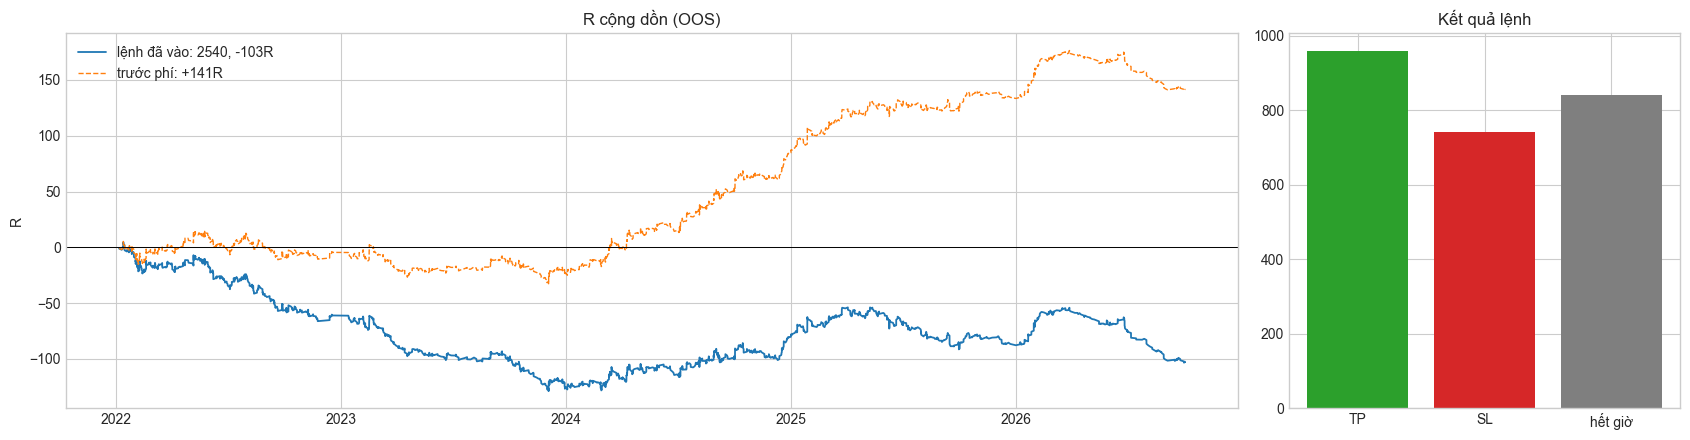

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(17, 4.5), gridspec_kw={"width_ratios": [3, 1]})
axes[0].plot(taken["time"], taken["R"].cumsum(), lw=1.3, label=f"lệnh đã vào: {len(taken)}, {taken['R'].sum():+.0f}R")
gross = taken["R"] + CFG.fee_roundtrip / taken["sl_pct"]
axes[0].plot(taken["time"], gross.cumsum(), lw=1, ls="--", label=f"trước phí: {gross.sum():+.0f}R")
axes[0].axhline(0, color="k", lw=0.7)
axes[0].set(title="R cộng dồn (OOS)", ylabel="R")
axes[0].legend()
cnt = taken["reason"].value_counts().reindex(["tp", "sl", "timeout"]).fillna(0)
axes[1].bar(["TP", "SL", "hết giờ"], cnt.to_numpy(), color=["tab:green", "tab:red", "tab:gray"])
axes[1].set_title("Kết quả lệnh")
plt.tight_layout()
plt.show()

## 5. 30 ngày gần nhất

In [9]:
recent = int(m1["t"].iloc[-1]) - RECENT_DAYS * 86_400_000
rec = taken[taken["t"] >= recent]
display(pd.DataFrame({"30 ngày": v3.trade_stats(rec)}).T.round(3))
display(rec[["time", "side", "close", "sl_pct", "ev", "p_tp", "p_sl", "reason", "R", "minutes", "E1", "E2", "E3"]].round(4).tail(40))

,trades,per_month,TP%,SL%,timeout%,win_of_resolved%,avg_R,ci90_lo,ci90_hi,total_R,max_dd_R,avg_minutes,long%
30 ngày,15.0,27.457,40.0,33.333,26.667,54.545,-0.089,-0.757,0.357,-1.328,4.363,118.4,80.0


,time,side,close,sl_pct,ev,p_tp,p_sl,reason,R,minutes,E1,E2,E3
653063,2026-09-15 14:00:00+00:00,-1,76588.4,0.0106,0.0610,0.3898,0.2348,tp,0.9060,41,1.0,0.0,0.0
653071,2026-09-15 14:40:00+00:00,-1,75834.0,0.0115,0.0881,0.3943,0.2193,sl,-1.0868,173,0.0,0.0,1.0
653926,2026-09-18 13:55:00+00:00,1,80020.0,0.0133,0.0527,0.3781,0.2505,tp,0.9250,91,1.0,1.0,1.0
653927,2026-09-18 14:00:00+00:00,1,80046.5,0.0133,0.0594,0.3665,0.2321,tp,0.9250,86,0.0,1.0,1.0
654157,2026-09-19 09:10:00+00:00,1,81433.3,0.0060,0.1026,0.4692,0.1999,timeout,-0.6126,240,0.0,0.0,1.0
654222,2026-09-19 14:35:00+00:00,1,81510.3,0.0060,0.0879,0.4432,0.1887,timeout,-0.3382,240,0.0,0.0,1.0
654727,2026-09-21 08:40:00+00:00,1,83494.4,0.0145,0.0585,0.3007,0.1735,tp,0.9313,54,1.0,1.0,1.0
654729,2026-09-21 08:50:00+00:00,1,83727.7,0.0147,0.0663,0.2761,0.1418,tp,0.9320,49,1.0,1.0,0.0
655602,2026-09-24 09:35:00+00:00,-1,82924.8,0.0112,0.0711,0.3804,0.2204,sl,-1.0889,225,1.0,0.0,0.0
655661,2026-09-24 14:30:00+00:00,1,84832.8,0.0103,0.0814,0.4549,0.2761,sl,-1.0974,19,1.0,0.0,1.0


## 6. Model cuối và lưu bundle

Model cuối train trên toàn bộ dữ liệu, trừ 365 ngày cuối: 60% đầu của khoảng này dùng để dừng sớm, 40% sau dùng để chọn ngưỡng. Worker live (`model-signals-v3`) đọc file bundle này.

In [10]:
t0 = time.time()
bundle = v3.train_final(data, CFG)
print(f"{time.time() - t0:.0f}s | ngưỡng R kỳ vọng: {bundle['threshold']}")
display(bundle["threshold_table"].round(3))
imp = pd.Series(bundle["fit"]["model"].get_booster().get_score(importance_type="gain"))
imp.index = [spec.names[int(k[1:])] for k in imp.index]
display(imp.sort_values(ascending=False).head(25).round(2).to_frame("gain"))

v3.save_bundle(bundle, OUT / "model_v3.joblib")
oos.to_csv(OUT / "oos_trades.csv", index=False)
wf["folds"].to_csv(OUT / "folds.csv", index=False)
meta = {"strategy": v3.STRATEGY, "config": bundle["config"], "threshold": bundle["threshold"],
        "trained_to_ms": bundle["trained_to_ms"], "features": spec.names,
        "oos_taken": {k: (float(v) if isinstance(v, (int, float, np.floating)) else v) for k, v in v3.trade_stats(taken).items()}}
(OUT / "metadata.json").write_text(json.dumps(meta, indent=2, default=str), encoding="utf-8")
print("Đã lưu vào", OUT)

44s | ngưỡng R kỳ vọng: 0.0


,thr,n,avg_R,lower
0,0.00,477,-0.125,-0.162
1,0.05,229,-0.169,-0.225
2,0.10,94,-0.147,-0.232
3,0.15,31,-0.032,-0.192
4,0.20,4,-0.208,-0.744
5,0.30,0,NaN,NaN
6,0.40,0,NaN,NaN


,gain
sigma_lvl,17.46
ev_rng,13.10
hour_cos,10.58
vr_48_2880,10.33
vr_12_288,8.46
hour_sin,7.79
zz10_brk,7.73
ev_ratio3,6.72
sl_log,6.52
zz10_age,6.51


Đã lưu vào C:\Users\thanh\BTC_PIPELINE\artifacts\5m_event_v3
